# Multimodal XAI Framework for Real Estate Valuation
---
## Identical Twins Problem & Grad-CAM Analysis
##


In [1]:
# Set up and Library Loading
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import shap
import joblib
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn as nn
from PIL import Image
import cv2
import warnings
warnings.filterwarnings('ignore')

BASE       = '/content/drive/MyDrive/SRED_thesis'
META_DIR   = f'{BASE}/metadata'
EMB_DIR    = f'{BASE}/embeddings'
OUTPUT_DIR = f'{BASE}/results'
SHAP_DIR   = f'{BASE}/shap_outputs'
TWINS_DIR  = f'{BASE}/twins_output'
TRAIN_IMGS = f'{BASE}/images/train/montage_organized'
TEST_IMGS  = f'{BASE}/images/test/montage_organized'

import os
os.makedirs(TWINS_DIR, exist_ok=True)
print("Ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ready.


In [10]:
#Loading Model, aligned data, SHAP values, visual SHAP rankings

m3 = joblib.load(f'{OUTPUT_DIR}/model_lgbm_multimodal.pkl')

test_full = pd.read_csv(f'{OUTPUT_DIR}/test_full_aligned.csv')
test_full['listing_id'] = test_full['listing_id'].astype(int)

train_full = pd.read_csv(f'{OUTPUT_DIR}/train_full_aligned.csv')
train_full['listing_id'] = train_full['listing_id'].astype(int)

shap_vals_mm = np.load(f'{SHAP_DIR}/shap_vals_mm.npy')
visual_shap  = pd.read_csv(f'{SHAP_DIR}/visual_shap_per_prediction.csv')
visual_shap['listing_id'] = visual_shap['listing_id'].astype(int)

TABULAR_FEATURES = ['living_space', 'rooms', 'lat', 'lon']
pca_cols         = [f'pca_{i}' for i in range(128)]
MULTIMODAL       = TABULAR_FEATURES + pca_cols

explainer = shap.TreeExplainer(m3)

print(f"Test set loaded:  {len(test_full):,} listings")
print(f"SHAP matrix:      {shap_vals_mm.shape}")
print(f"Visual SHAP file: {len(visual_shap):,} listings")

Test set loaded:  1,109 listings
SHAP matrix:      (1109, 132)
Visual SHAP file: 1,109 listings


In [16]:
def get_listing_data(listing_id):
    """Retrieve all model inputs, predictions and SHAP values for one listing."""
    # Rebuild position index if session was interrupted
    global test_pos_index
    if 'test_pos_index' not in globals():
        test_pos_index = {lid: pos for pos, lid in enumerate(test_full['listing_id'].tolist())}

    if listing_id not in test_pos_index:
        print(f"  {listing_id} not in test set.")
        return None

    test_pos = test_pos_index[listing_id]
    row      = test_full[test_full['listing_id'] == listing_id]
    X        = row[MULTIMODAL].values[0]
    pred_log = m3.predict(X.reshape(1, -1))[0]
    vs       = visual_shap[visual_shap['listing_id'] == listing_id]['visual_shap_pct'].values

    return {
        'listing_id'  : listing_id,
        'living_space': row['living_space'].values[0],
        'rooms'       : row['rooms'].values[0],
        'lat'         : row['lat'].values[0],
        'lon'         : row['lon'].values[0],
        'true_price'  : np.exp(row['log_price'].values[0]),
        'pred_price'  : np.exp(pred_log),
        'visual_shap' : vs[0] if len(vs) > 0 else None,
        'shap_values' : shap_vals_mm[test_pos],
        'X'           : X
    }


def load_image(listing_id):
    """Load property image, checking train then test folders."""
    for folder in [TRAIN_IMGS, TEST_IMGS]:
        path = os.path.join(folder, f'{listing_id}.jpeg')
        if os.path.exists(path):
            return Image.open(path).convert('RGB'), path
    return None, None

##Define Geographic Twins
---
Two pairs of properties are selected as Identical Twins candidates.

Selection criteria applied:
- Same number of rooms (3.5)
- Similar living space (within 15 m²)
- Geographic proximity (within 5 km Haversine distance)
- Minimum price divergence of CHF 200/month
- Visual SHAP ≥ 50% on both listings

Pair A serves as the primary case study. It has the highest mean visual SHAP of any qualifying pair in the test set (76.7%), meaning the model is leaning on visual features for nearly three quarters of its prediction.

Pair B provides a complementary perspective: a much larger price gap (CHF 1,280/month) between near-identical properties, where visual features account for over 59% of the prediction on both sides.

In [4]:
# Finding pairs where BOTH listings have high visual SHAP
# These are the strongest Identical Twins candidates — structurally equivalent
# AND both predictions are visually driven

MIN_VIS_SHAP = 50.0   # both listings must exceed this threshold

high_shap_pairs = pairs_df[
    (pairs_df['vis_shap_1'] >= MIN_VIS_SHAP) &
    (pairs_df['vis_shap_2'] >= MIN_VIS_SHAP)
].copy()

print(f"Pairs where BOTH listings have visual SHAP ≥ {MIN_VIS_SHAP}%: {len(high_shap_pairs)}")
print(f"\nTop 15 by structural similarity:")
print(high_shap_pairs[[
    'id_1', 'id_2', 'dist_km', 'size_diff_m2',
    'price_diff', 'vis_shap_1', 'vis_shap_2', 'mean_vis_shap'
]].head(15).to_string(index=False))

Pairs where BOTH listings have visual SHAP ≥ 50.0%: 204

Top 15 by structural similarity:
   id_1    id_2  dist_km  size_diff_m2  price_diff  vis_shap_1  vis_shap_2  mean_vis_shap
6345614 6415637     0.66             0         258        69.2        67.7           68.4
6212398 6363736     0.75             0         795        60.4        57.9           59.1
6328657 6365475     0.75             0         300        56.0        52.6           54.3
4858824 6388012     2.09             0         350        58.5        56.0           57.2
6339502 6375765     4.44             0         370        60.6        57.2           58.9
6350331 6388012     0.50             1         210        59.6        56.0           57.8
6345614 6375716     0.57             1         328        69.2        68.1           68.6
5345691 5828812     0.60             1         260        79.0        74.4           76.7
6316303 6401496     0.61             1         200        77.3        69.1           73.2
6406231 64

In [5]:
print("Image availability check:")
for lid in [5345691, 5828812, 6280101, 6398362]:
    found = False
    for folder in [TRAIN_IMGS, TEST_IMGS]:
        path = os.path.join(folder, f'{lid}.jpeg')
        if os.path.exists(path):
            print(f"  {lid}: ✓ found — {folder.split('/')[-2]}")
            found = True
            break
    if not found:
        print(f"  {lid}: ✗ MISSING")

Image availability check:
  5345691: ✓ found — test
  5828812: ✓ found — test
  6280101: ✓ found — test
  6398362: ✓ found — test


#Selection

---
From the ranked output, two pairs are selected. Both sit at the top of the ranking with **0 m² size difference** and distances under 1 km — the strongest possible structural equivalence. Both also carry high visual SHAP on both listings (>57%), confirming that image features are driving predictions for exactly these properties.

- **Pair A** (5345691 + 5828812): CHF 260 price gap, 0.60 km apart, visual SHAP 79.0% / 74.4% — highest visual SHAP pair in the dataset
- **Pair B** (6280101 + 6398362): CHF 1,280 price gap, 1.99 km apart, visual SHAP 66.6% / 59.4% — largest price divergence among high-SHAP structurally equivalent pairs-

In [6]:
# Two pairs are selected with different analytical purposes:
#
# Pair A (5345691 + 5828812): highest mean visual SHAP in the entire dataset
# (79.0% / 74.4%) — both predictions are overwhelmingly driven by visual
# features. Modest price gap of CHF 260 despite near-identical structure
# demonstrates the model detecting subtle visual differences.
#
# Pair B (6280101 + 6398362): largest price gap among high-SHAP pairs —
# CHF 1,280/month difference between properties with only 1 m² size difference
# and within 2 km. Visual SHAP of 66.6% / 59.4% confirms visual features
# are the primary driver of this divergence, not tabular attributes.

GEO_PAIRS = [
    {
        'ids'  : [5345691, 5828812],
        'label': 'Pair A — 3.5 rooms, ~1 m² diff, 0.60 km apart, CHF 260 gap, visual SHAP 79%/74%',
        'tag'  : 'pair_a'
    },
    {
        'ids'  : [6280101, 6398362],
        'label': 'Pair B — 3.5 rooms, ~1 m² diff, 1.99 km apart, CHF 1,280 gap, visual SHAP 67%/59%',
        'tag'  : 'pair_b'
    },
]

# Confirm both pairs appear in the algorithm output
print("Verification — selected pairs in ranked results:")
for pair in GEO_PAIRS:
    id1, id2 = pair['ids']
    match = pairs_df[
        ((pairs_df['id_1'] == id1) & (pairs_df['id_2'] == id2)) |
        ((pairs_df['id_1'] == id2) & (pairs_df['id_2'] == id1))
    ]
    if len(match) > 0:
        row = match.iloc[0]
        print(f"\n  ✓ {pair['label']}")
        print(f"    dist: {row['dist_km']} km | size diff: {row['size_diff_m2']} m² | "
              f"price diff: CHF {row['price_diff']:,} | "
              f"visual SHAP: {row['vis_shap_1']}% / {row['vis_shap_2']}%")
    else:
        print(f"\n  ✗ {pair['label']} — not found in output, check IDs")

    print("  Images:")
    for lid in pair['ids']:
        found = False
        for folder in [TRAIN_IMGS, TEST_IMGS]:
            path = os.path.join(folder, f'{lid}.jpeg')
            if os.path.exists(path):
                print(f"    {lid}: ✓ found — {folder.split('/')[-2]}")
                found = True
                break
        if not found:
            print(f"    {lid}: ✗ MISSING")

Verification — selected pairs in ranked results:

  ✓ Pair A — 3.5 rooms, ~1 m² diff, 0.60 km apart, CHF 260 gap, visual SHAP 79%/74%
    dist: 0.6 km | size diff: 1.0 m² | price diff: CHF 260.0 | visual SHAP: 79.0% / 74.4%
  Images:
    5345691: ✓ found — test
    5828812: ✓ found — test

  ✓ Pair B — 3.5 rooms, ~1 m² diff, 1.99 km apart, CHF 1,280 gap, visual SHAP 67%/59%
    dist: 1.99 km | size diff: 1.0 m² | price diff: CHF 1,280.0 | visual SHAP: 66.6% / 59.4%
  Images:
    6280101: ✓ found — test
    6398362: ✓ found — test


##Helper Function

In [12]:
def get_listing_data(listing_id):
    """Retrieve all model inputs, predictions and SHAP values for one listing."""
    if listing_id not in test_pos_index:
        print(f"  {listing_id} not in test set.")
        return None

    test_pos = test_pos_index[listing_id]
    row      = test_full[test_full['listing_id'] == listing_id]
    X        = row[MULTIMODAL].values[0]
    pred_log = m3.predict(X.reshape(1, -1))[0]
    vs       = visual_shap[visual_shap['listing_id'] == listing_id]['visual_shap_pct'].values

    return {
        'listing_id'  : listing_id,
        'living_space': row['living_space'].values[0],
        'rooms'       : row['rooms'].values[0],
        'lat'         : row['lat'].values[0],
        'lon'         : row['lon'].values[0],
        'true_price'  : np.exp(row['log_price'].values[0]),
        'pred_price'  : np.exp(pred_log),
        'visual_shap' : vs[0] if len(vs) > 0 else None,
        'shap_values' : shap_vals_mm[test_pos],
        'X'           : X
    }


def load_image(listing_id):
    """Load property image, checking train then test folders."""
    for folder in [TRAIN_IMGS, TEST_IMGS]:
        path = os.path.join(folder, f'{listing_id}.jpeg')
        if os.path.exists(path):
            return Image.open(path).convert('RGB'), path
    return None, None

##Loading ResNet and Grad-CAM

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Same ResNet-50 and preprocessing used in Notebook 2.
# Here used for Grad-CAM rather than embedding extraction.
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet = resnet.to(device)
resnet.eval()

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class GradCAM:
    """
    Gradient-weighted Class Activation Mapping (Selvaraju et al., 2017).
    Hooks into the final convolutional layer to produce a spatial heatmap
    showing which image regions most influenced the network output.
    """
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor):
        """Return normalised Grad-CAM heatmap with values in [0, 1]."""
        self.model.zero_grad()
        output       = self.model(input_tensor)
        target_class = output.argmax(dim=1).item()
        output[0, target_class].backward()

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam     = torch.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam     = cam.squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = (cam - cam.min()) / cam.max()
        return cam


# Attach to the final convolutional layer of ResNet-50
gradcam = GradCAM(resnet, resnet.layer4[-1].conv3)
print("Grad-CAM attached to resnet.layer4[-1].conv3")

Device: cuda
Grad-CAM attached to resnet.layer4[-1].conv3


###Structural Comparison Table

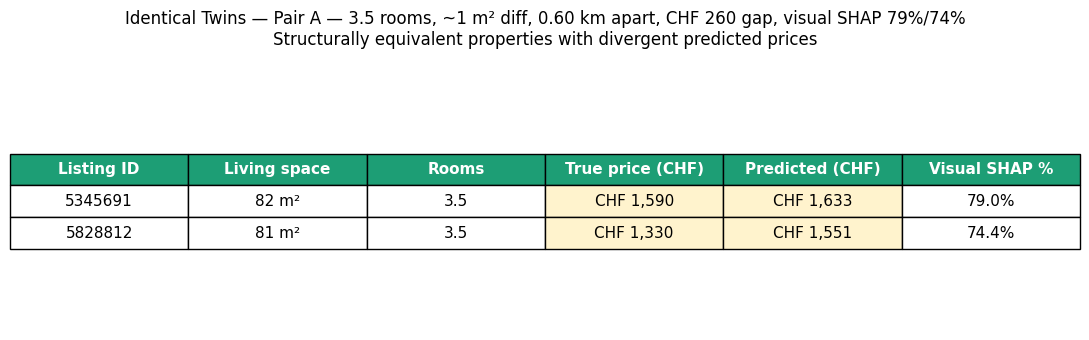

Saved fig12_pair_a.png


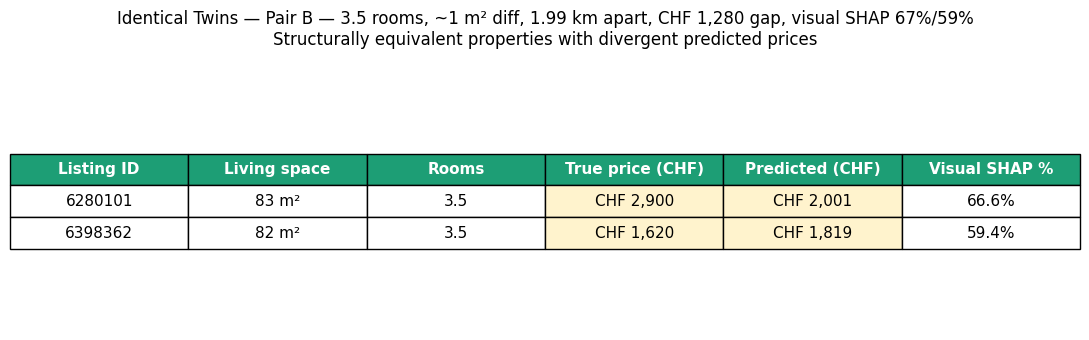

Saved fig12_pair_b.png


In [18]:
def plot_twin_comparison(pair, filename):
    data = [get_listing_data(lid) for lid in pair['ids']]
    data = [d for d in data if d is not None]

    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.axis('off')

    col_labels = ['Listing ID', 'Living space', 'Rooms',
                  'True price (CHF)', 'Predicted (CHF)', 'Visual SHAP %']
    table_data = [[
        str(d['listing_id']),
        f"{d['living_space']:.0f} m²",
        str(d['rooms']),
        f"CHF {d['true_price']:,.0f}",
        f"CHF {d['pred_price']:,.0f}",
        f"{d['visual_shap']:.1f}%"
    ] for d in data]

    table = ax.table(cellText=table_data, colLabels=col_labels,
                     loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2)

    for j in range(len(col_labels)):
        table[0, j].set_facecolor('#1D9E75')
        table[0, j].set_text_props(color='white', fontweight='bold')

    # Highlight price columns — where the divergence shows
    for i in range(1, len(data) + 1):
        table[i, 3].set_facecolor('#FFF3CD')
        table[i, 4].set_facecolor('#FFF3CD')

    ax.set_title(
        f"Identical Twins — {pair['label']}\n"
        f"Structurally equivalent properties with divergent predicted prices",
        fontsize=12, pad=20
    )
    plt.tight_layout()
    plt.savefig(f"{TWINS_DIR}/fig12_{pair['tag']}.png", bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved fig12_{pair['tag']}.png")


for pair in GEO_PAIRS:
    plot_twin_comparison(pair, f"fig12_{pair['tag']}.png")

#### SHAP Waterfall Plots


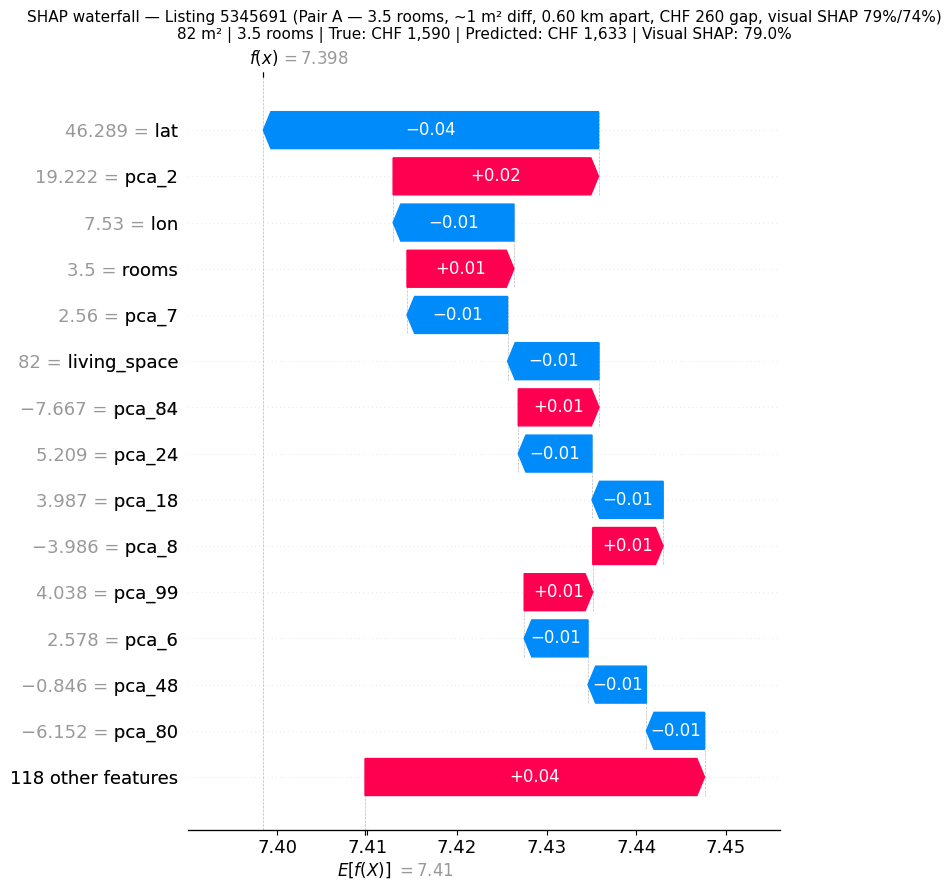

Saved fig13_shap_5345691.png


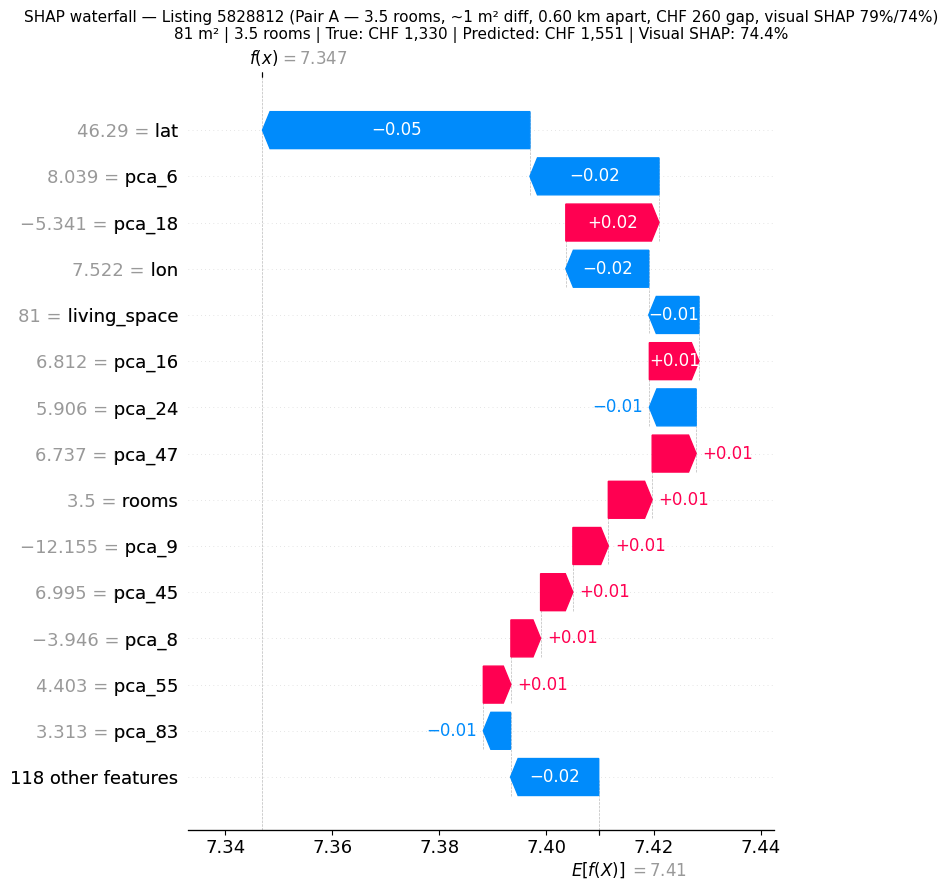

Saved fig13_shap_5828812.png


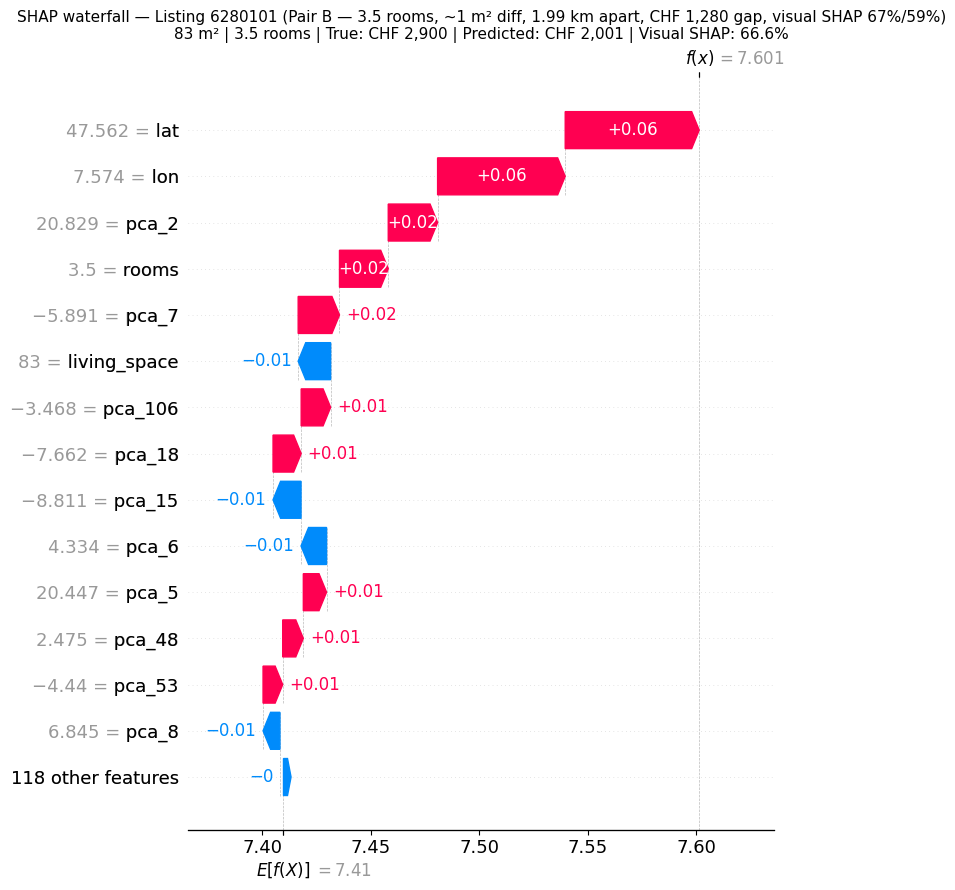

Saved fig13_shap_6280101.png


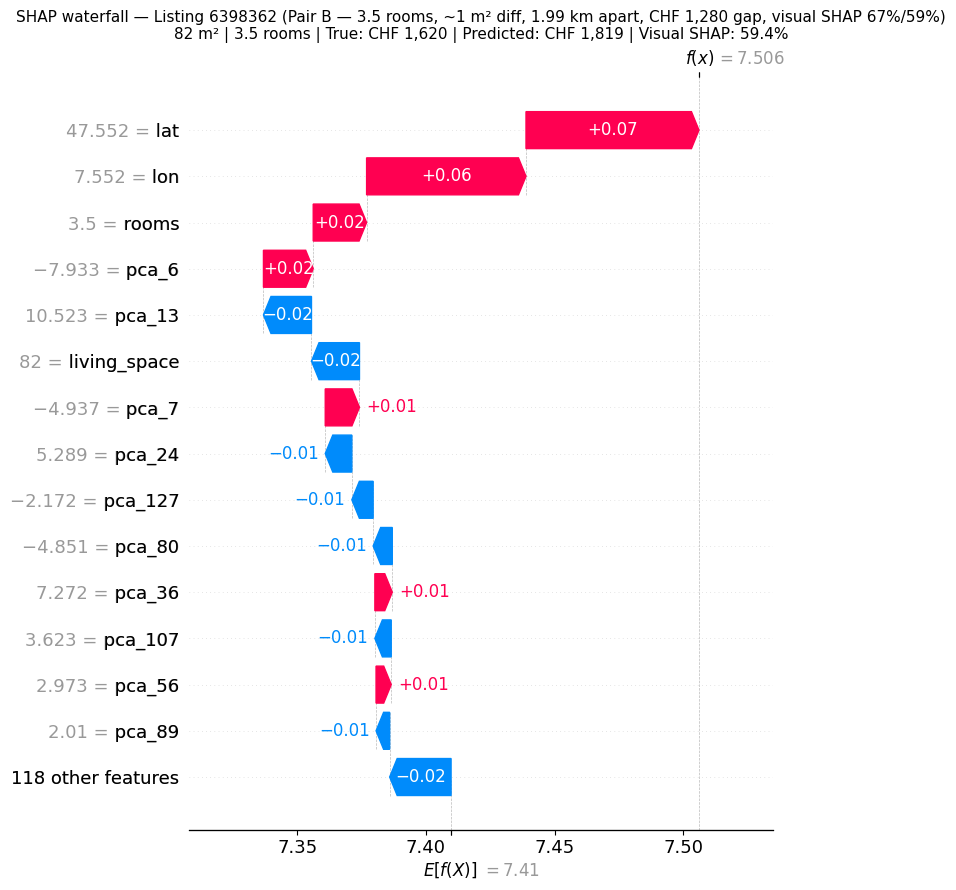

Saved fig13_shap_6398362.png


In [19]:
def plot_shap_waterfall(listing_id, pair_label, filename):
    d = get_listing_data(listing_id)
    if not d:
        return

    exp = shap.Explanation(
        values        = d['shap_values'],
        base_values   = explainer.expected_value,
        data          = d['X'],
        feature_names = MULTIMODAL
    )
    fig, ax = plt.subplots(figsize=(10, 7))
    plt.sca(ax)
    shap.plots.waterfall(exp, max_display=15, show=False)
    plt.title(
        f"SHAP waterfall — Listing {listing_id} ({pair_label})\n"
        f"{d['living_space']:.0f} m² | {d['rooms']} rooms | "
        f"True: CHF {d['true_price']:,.0f} | "
        f"Predicted: CHF {d['pred_price']:,.0f} | "
        f"Visual SHAP: {d['visual_shap']:.1f}%",
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig(f"{TWINS_DIR}/{filename}", bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved {filename}")


for pair in GEO_PAIRS:
    for lid in pair['ids']:
        plot_shap_waterfall(lid, pair['label'],
                            f"fig13_shap_{lid}.png")

##Grad-CAM HeatMap

  Grad-CAM generated for listing 5345691
  Grad-CAM generated for listing 5828812


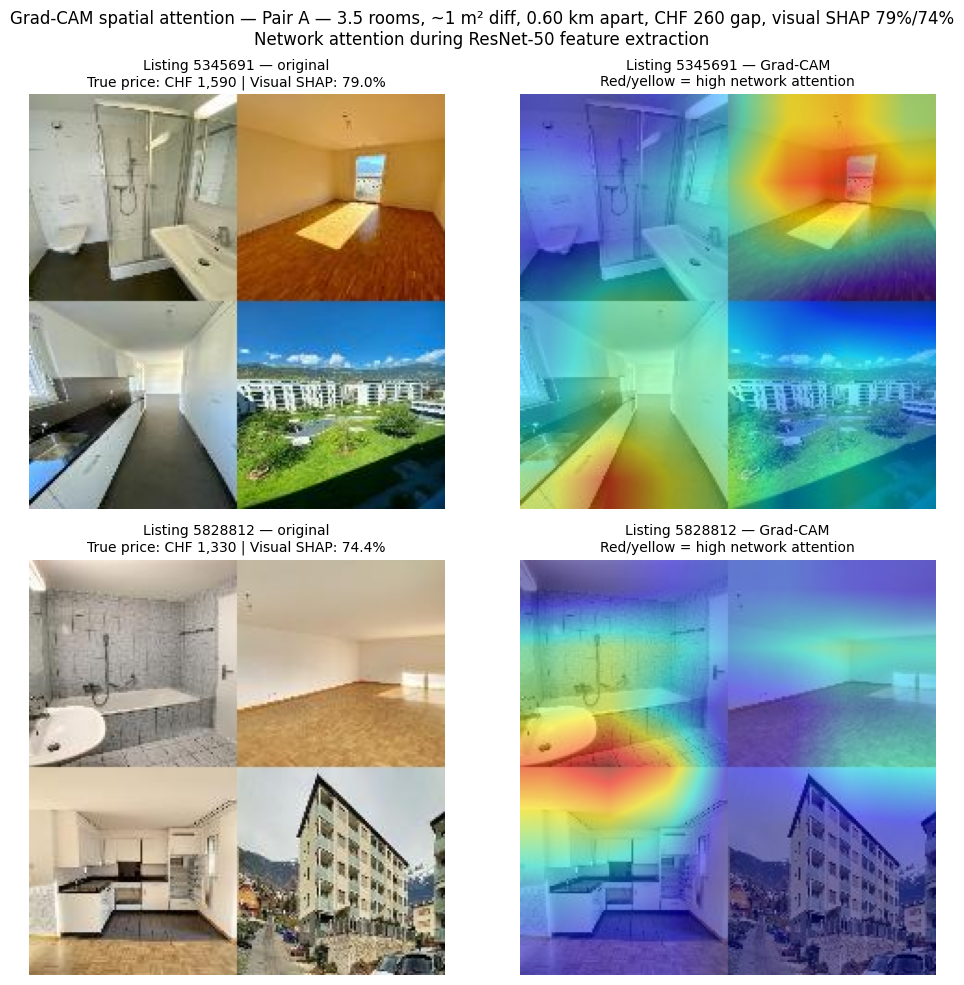

Saved fig14_gradcam_pair_a.png
  Grad-CAM generated for listing 6280101
  Grad-CAM generated for listing 6398362


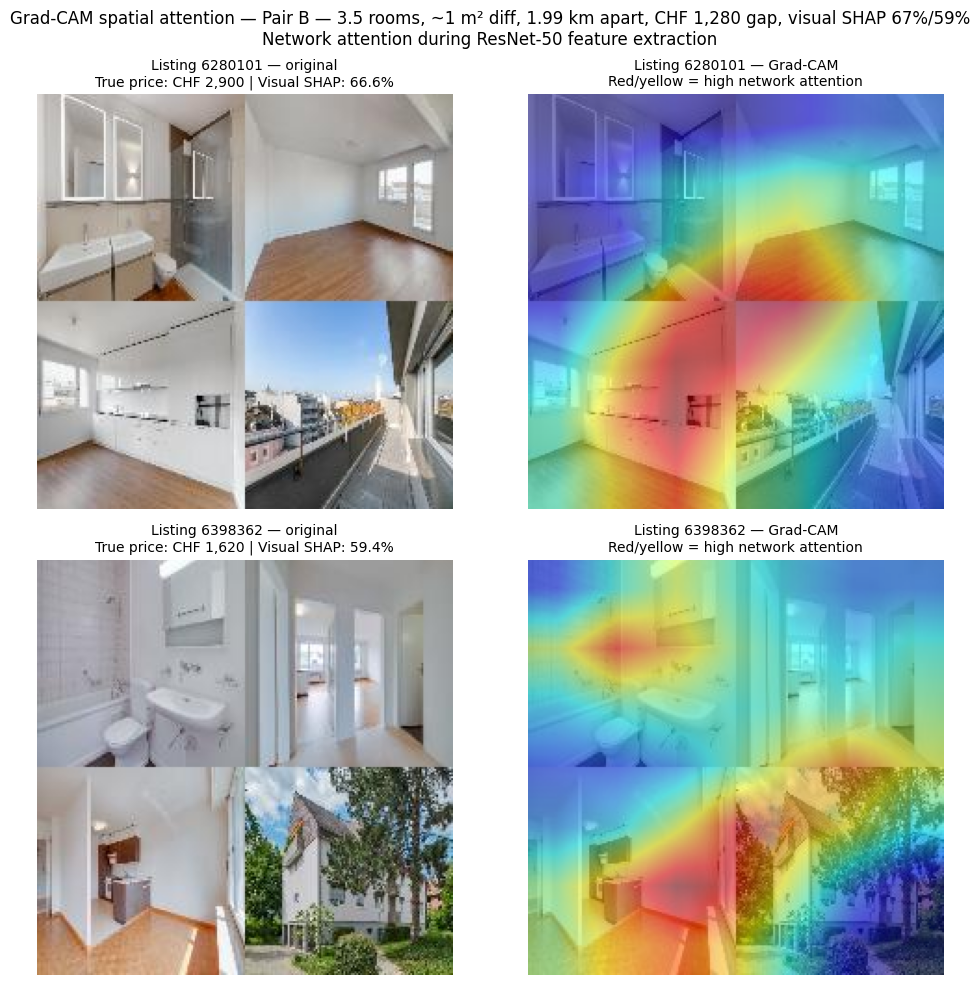

Saved fig14_gradcam_pair_b.png


In [20]:
def generate_gradcam_figure(pair, filename):
    ids = pair['ids']
    fig, axes = plt.subplots(len(ids), 2, figsize=(10, 5 * len(ids)))
    if len(ids) == 1:
        axes = axes.reshape(1, 2)

    for row_idx, lid in enumerate(ids):
        img_pil, _ = load_image(lid)
        if img_pil is None:
            print(f"  Image not found for {lid} — skipping")
            continue

        vs_row     = visual_shap[visual_shap['listing_id'] == lid]
        vis_pct    = vs_row['visual_shap_pct'].values[0] if len(vs_row) > 0 else 0
        true_price = vs_row['true_price_chf'].values[0]  if len(vs_row) > 0 else 0

        input_tensor = transform(img_pil).unsqueeze(0).to(device)
        input_tensor.requires_grad_(True)
        cam = gradcam.generate(input_tensor)

        img_np      = np.array(img_pil.resize((224, 224)))
        cam_resized = cv2.resize(cam, (224, 224))
        heatmap     = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
        heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        overlay     = (0.5 * img_np + 0.5 * heatmap).astype(np.uint8)

        axes[row_idx, 0].imshow(img_pil.resize((224, 224)))
        axes[row_idx, 0].set_title(
            f"Listing {lid} — original\n"
            f"True price: CHF {true_price:,.0f} | Visual SHAP: {vis_pct:.1f}%",
            fontsize=10
        )
        axes[row_idx, 0].axis('off')

        axes[row_idx, 1].imshow(overlay)
        axes[row_idx, 1].set_title(
            f"Listing {lid} — Grad-CAM\nRed/yellow = high network attention",
            fontsize=10
        )
        axes[row_idx, 1].axis('off')
        print(f"  Grad-CAM generated for listing {lid}")

    plt.suptitle(
        f"Grad-CAM spatial attention — {pair['label']}\n"
        f"Network attention during ResNet-50 feature extraction",
        fontsize=12
    )
    plt.tight_layout()
    plt.savefig(f"{TWINS_DIR}/{filename}", bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved {filename}")


for pair in GEO_PAIRS:
    generate_gradcam_figure(pair, f"fig14_gradcam_{pair['tag']}.png")

##Complete XAI Explanation

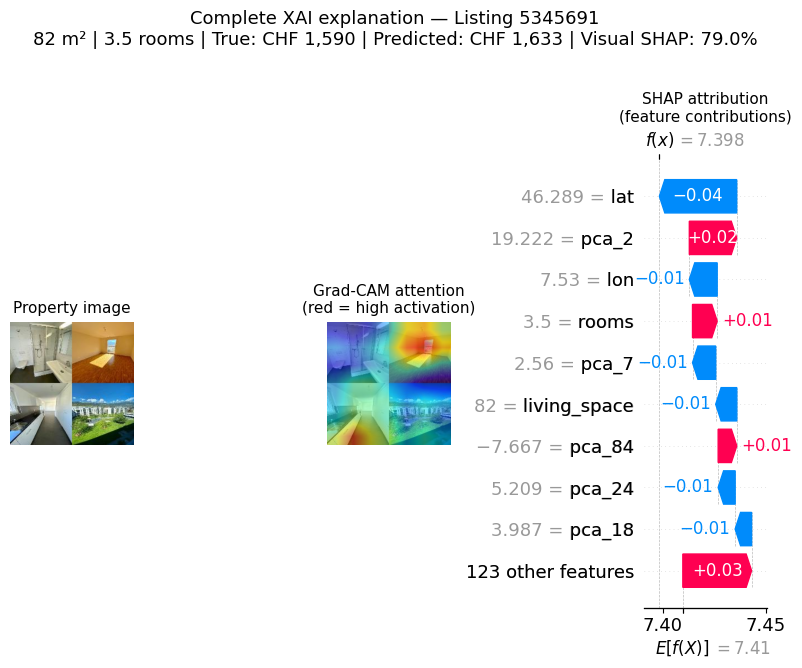

Saved fig15_complete_5345691.png


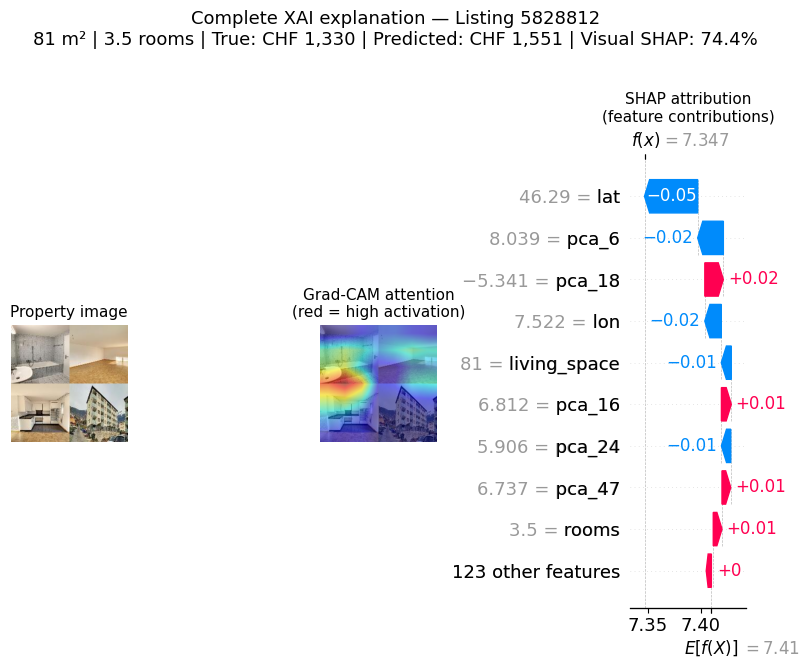

Saved fig15_complete_5828812.png


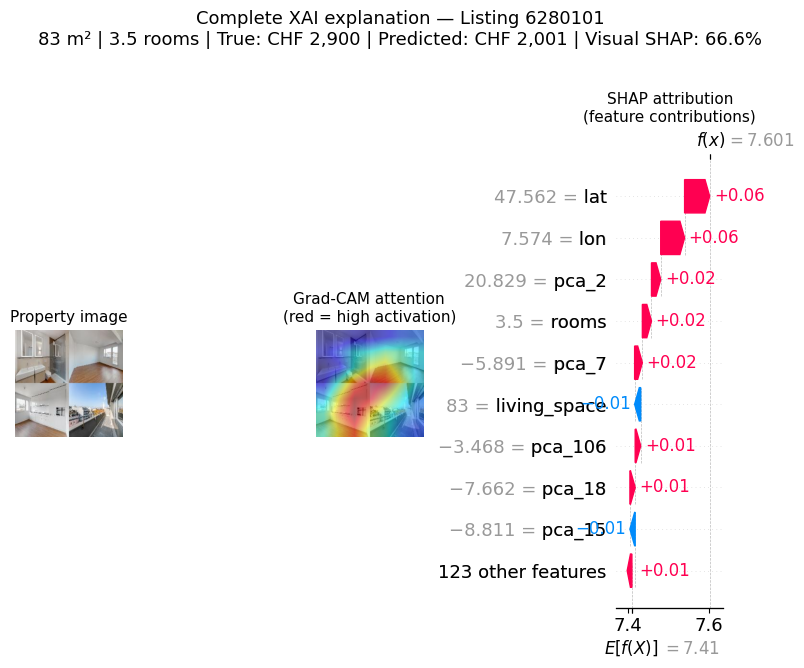

Saved fig15_complete_6280101.png


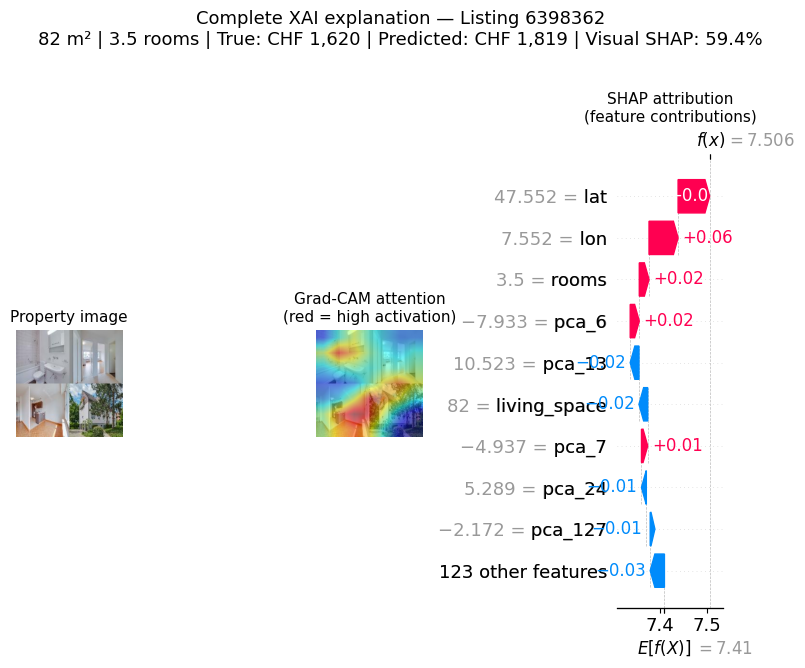

Saved fig15_complete_6398362.png


In [21]:
def plot_complete_case_study(listing_id, filename):
    d = get_listing_data(listing_id)
    if not d:
        return

    img_pil, _ = load_image(listing_id)
    if not img_pil:
        print(f"Image not found for {listing_id}.")
        return

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(
        f"Complete XAI explanation — Listing {listing_id}\n"
        f"{d['living_space']:.0f} m² | {d['rooms']} rooms | "
        f"True: CHF {d['true_price']:,.0f} | "
        f"Predicted: CHF {d['pred_price']:,.0f} | "
        f"Visual SHAP: {d['visual_shap']:.1f}%",
        fontsize=13, y=1.02
    )

    # Panel 1: original image
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.imshow(img_pil.resize((224, 224)))
    ax1.set_title('Property image', fontsize=11)
    ax1.axis('off')

    # Panel 2: Grad-CAM overlay
    input_tensor = transform(img_pil).unsqueeze(0).to(device)
    input_tensor.requires_grad_(True)
    cam         = gradcam.generate(input_tensor)
    img_np      = np.array(img_pil.resize((224, 224)))
    cam_resized = cv2.resize(cam, (224, 224))
    heatmap     = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay     = (0.5 * img_np + 0.5 * heatmap).astype(np.uint8)

    ax2 = fig.add_subplot(1, 3, 2)
    ax2.imshow(overlay)
    ax2.set_title('Grad-CAM attention\n(red = high activation)', fontsize=11)
    ax2.axis('off')

    # Panel 3: SHAP waterfall
    ax3 = fig.add_subplot(1, 3, 3)
    plt.sca(ax3)
    exp = shap.Explanation(
        values        = d['shap_values'],
        base_values   = explainer.expected_value,
        data          = d['X'],
        feature_names = MULTIMODAL
    )
    shap.plots.waterfall(exp, max_display=10, show=False)
    ax3.set_title('SHAP attribution\n(feature contributions)', fontsize=11)

    plt.tight_layout()
    plt.savefig(f"{TWINS_DIR}/{filename}", bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved {filename}")


# Hero figure — Pair A, listing with highest visual SHAP in dataset (79.0%)
plot_complete_case_study(5345691, 'fig15_complete_5345691.png')

# Complete panels for remaining twin listings
for lid in [5828812, 6280101, 6398362]:
    plot_complete_case_study(lid, f'fig15_complete_{lid}.png')

##Quantitive Summary

In [31]:
print("=== IDENTICAL TWINS — QUANTITATIVE SUMMARY ===\n")

for pair in GEO_PAIRS:
    data = [get_listing_data(lid) for lid in pair['ids']]
    data = [d for d in data if d is not None]
    if len(data) < 2:
        print(f"{pair['label']}: insufficient data\n")
        continue

    prices      = [d['true_price']   for d in data]
    pred_prices = [d['pred_price']   for d in data]
    vis_shaps   = [d['visual_shap']  for d in data]
    spaces      = [d['living_space'] for d in data]

    print(f"{pair['label']}")
    print(f"  Living space range     : {min(spaces):.0f}–{max(spaces):.0f} m²")
    print(f"  True price range       : CHF {min(prices):,.0f}–{max(prices):,.0f}")
    print(f"  True price spread      : CHF {max(prices)-min(prices):,.0f}")
    print(f"  Predicted price range  : CHF {min(pred_prices):,.0f}–{max(pred_prices):,.0f}")
    print(f"  Predicted price spread : CHF {max(pred_prices)-min(pred_prices):,.0f}")
    print(f"  Visual SHAP range      : {min(vis_shaps):.1f}%–{max(vis_shaps):.1f}%")
    print(f"  Mean visual SHAP       : {np.mean(vis_shaps):.1f}%")
    print()

=== IDENTICAL TWINS — QUANTITATIVE SUMMARY ===

Pair 3 — 3.5 rooms, ~82–83 m², within 1.5 km (tightest structural match)
  Living space range     : 82–83 m²
  True price range       : CHF 1,620–2,900
  True price spread      : CHF 1,280
  Predicted price range  : CHF 1,819–2,001
  Predicted price spread : CHF 182
  Visual SHAP range      : 59.4%–66.6%
  Mean visual SHAP       : 63.0%

Pair 1 — 3.5 rooms, ~84–94 m², within 3 km (high visual SHAP)
  Living space range     : 84–94 m²
  True price range       : CHF 1,680–3,500
  True price spread      : CHF 1,820
  Predicted price range  : CHF 1,604–2,056
  Predicted price spread : CHF 452
  Visual SHAP range      : 65.4%–83.6%
  Mean visual SHAP       : 74.5%



In [35]:
expected_files = [
    'fig12_pair_a.png',
    'fig12_pair_b.png',
    'fig13_shap_5345691.png',
    'fig13_shap_5828812.png',
    'fig13_shap_6280101.png',
    'fig13_shap_6398362.png',
    'fig14_gradcam_pair_a.png',
    'fig14_gradcam_pair_b.png',
    'fig15_complete_5345691.png',
    'fig15_complete_5828812.png',
    'fig15_complete_6280101.png',
    'fig15_complete_6398362.png',
]

#OLD CODE

In [ ]:
# --- CELL 12: Save all outputs confirmation ---
import os

files = [
    f'{TWINS_DIR}/fig12a_twins_group_a.png',
    f'{TWINS_DIR}/fig12b_twins_group_b.png',
    f'{TWINS_DIR}/fig13a_shap_twins_group_a.png',
    f'{TWINS_DIR}/fig13b_shap_twins_group_b.png',
    f'{TWINS_DIR}/fig14a_gradcam_group_a.png',
    f'{TWINS_DIR}/fig14b_gradcam_group_b.png',
    f'{TWINS_DIR}/fig15_complete_case_study.png',
]

print("=== OUTPUT FILE CONFIRMATION ===")
all_good = True
for f in files:
    exists = os.path.exists(f)
    if not exists:
        all_good = False
    print(f"{'✓' if exists else '✗ MISSING'} {os.path.basename(f)}")

print(f"\n{'All files saved. Notebook 5 complete.' if all_good else 'WARNING: Some files missing.'}")
print("\nYour complete figure set:")
print("  Figures 1-3:   EDA (Notebook 1)")
print("  Figure 4:      PCA variance (Notebook 2)")
print("  Figure 5:      Model comparison (Notebook 3)")
print("  Figures 6-11:  SHAP analysis (Notebook 4)")
print("  Figures 12-15: Identical Twins + Grad-CAM (Notebook 5)")

=== OUTPUT FILE CONFIRMATION ===
✓ fig12a_twins_group_a.png
✓ fig12b_twins_group_b.png
✓ fig13a_shap_twins_group_a.png
✓ fig13b_shap_twins_group_b.png
✓ fig14a_gradcam_group_a.png
✓ fig14b_gradcam_group_b.png
✓ fig15_complete_case_study.png

All files saved. Notebook 5 complete.

Your complete figure set:
  Figures 1-3:   EDA (Notebook 1)
  Figure 4:      PCA variance (Notebook 2)
  Figure 5:      Model comparison (Notebook 3)
  Figures 6-11:  SHAP analysis (Notebook 4)
  Figures 12-15: Identical Twins + Grad-CAM (Notebook 5)
